<h1>1. Import library</h1>

In [ ]:
############# Importing System Libraries #############
import sys
import os
import cv2
project_dir = "/data2/atran16/ProteinClassification_AnhTuanTran"

############# Importing support Libraries #############
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
############# Importing datasets classes #############

sys.path.append(f"{project_dir}/utils/datasets")
from pdb_ds import test_tf

############# Importing models #############
sys.path.append(f"{project_dir}")
from models import (
    load_Resnet50,
    load_ConvNeXt,
    load_CoAtNet2,
    load_EfficientNetV2,
    load_VIT_SizeT,
    load_RegNetY16GF,
    load_SwinV2B,
)

class_names = {0: '1CQZ', 1: '1CR6', 2: '1EK1', 3: '1EK2', 4: '1LCP', 5: '1LK2', 6: '1R8X', 7: '1R8Y', 8: '1XFB', 
               9: '1Y5M', 10: '1Y5R', 11: '1Z7L', 12: '2A73', 13: '2DJ1', 14: '2DJ2', 15: '2DJ3', 16: '2DML', 
               17: '2FMU', 18: '2LZJ', 19: '2V31', 20: '3CQX', 21: '3EMN', 22: '3GB5', 23: '3GFD', 24: '3GH8', 
               25: '3GMD', 26: '3O0V', 27: '3O0W', 28: '3O0X', 29: '3OQC', 30: '3RG0', 31: '3TNZ', 32: '3TO0', 
               33: '3U0Z', 34: '4B90', 35: '4BKN', 36: '4C69', 37: '4K26', 38: '4NMH', 39: '4NOB', 40: '4NOF', 
               41: '4O25', 42: '4O2L', 43: '4O2R', 44: '4P58', 45: '4P7F', 46: '4YMK', 47: '5AXA', 48: '5AXB', 
               49: '5AXC', 50: '5AXD', 51: '5F0E', 52: '5FTK', 53: '5GU5', 54: '5H9O', 55: '5HJO', 56: '5HJR', 
               57: '5IED', 58: '5IEE', 59: '5IEF', 60: '5IEG', 61: '5IKO', 62: '5MTV', 63: '5MVF', 64: '5PGZ', 
               65: '5QIJ', 66: '5YQG', 67: '5YZH', 68: '5YZI', 69: '6QNP', 70: '6TTH', 71: '6UV5', 72: '6WF2', 
               73: '6XZU', 74: '7EPM', 75: '7EXE', 76: '7JG2', 77: '7JTY', 78: '7K9N', 79: '7K9O', 80: '7K9Q', 
               81: '7K9T', 82: '7KAD', 83: '7KB6', 84: '7KB8', 85: '7KBJ', 86: '7KBR', 87: '7KRY', 88: '7KUH', 
               89: '7L7J', 90: '7L9E', 91: '7O37', 92: '7O3C', 93: '7O3E', 94: '7O3H', 95: '7SL1', 96: '7SL2', 
               97: '7SL3', 98: '7SL4', 99: '7SL6', 100: '7SL7', 101: '7SOX', 102: '7STH', 103: '7STI', 104: '7STJ', 
               105: '7STK', 106: '7U5I', 107: '7WTA', 108: '7Y04', 109: '7Y1B', 110: '7Y1Q', 111: '7YOB', 112: '8COD',
               113: '8DNM', 114: '8DNO', 115: '8DNP', 116: '8DNS', 117: '8DNU', 118: '8DTL', 119: '8DTM', 120: '8EYI', 
               121: '8EYX', 122: '8EYY', 123: '8EZ0', 124: '8H77', 125: '8KIB', 126: '8W49'}
topk=(1,3,5,10,20)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
configs = {"model": "CoAtNet", "n_classes":127, "pretrained_path":""}

In [9]:
if configs["model"] == "Resnet50":
    model = load_Resnet50(num_classes = configs["n_classes"], pretrained_path=configs["pretrained_path"], device=device)
    model = model.to(device)
    print("Loading ResNet50 model successfully!\n")
elif configs["model"] == "ConvNeXt":
    model = load_ConvNeXt(num_classes = configs["n_classes"], pretrained_path=configs["pretrained_path"], device=device)
    model = model.to(device)
    print("Loading ConvNeXt model successfully!\n")
elif configs["model"] == "CoAtNet":
    model = load_CoAtNet2(num_classes = configs["n_classes"], pretrained_path=configs["pretrained_path"], device=device)
    model = model.to(device)
    print("Loading CoAtNet2 model successfully!\n")
elif configs["model"] == "EfficientNetV2":
    model = load_EfficientNetV2(num_classes = configs["n_classes"], pretrained_path=configs["pretrained_path"], device=device)
    model = model.to(device)
    print("Loading EfficientNetV2_s model successfully!\n")
elif configs["model"] == "MaxViT":
    model = load_VIT_SizeT(num_classes = configs["n_classes"], pretrained_path=configs["pretrained_path"], device=device)
    model = model.to(device)
    print("Loading MaxViT_SizeT model successfully!\n")
elif configs["model"] == "RegNetY16GF":
    model = load_RegNetY16GF(num_classes = configs["n_classes"], pretrained_path=configs["pretrained_path"], device=device)
    model = model.to(device)
    print("Loading RegNetY16GF model successfully!\n")
elif configs["model"] == "SwinV2B":
    model = load_SwinV2B(num_classes = configs["n_classes"], pretrained_path=configs["pretrained_path"], device=device)
    model = model.to(device)
    print("Loading SwinV2B model successfully!\n")
else:
    raise ValueError(f"Unsupported model type: {configs['model']}")

Loading CoAtNet2 model successfully!



[(115, 0.9222363233566284), (117, 0.05180719122290611), (17, 0.02456851676106453), (114, 0.0012617339380085468), (45, 0.00012601219350472093), (88, 2.0600744221610512e-07), (21, 2.123998060765686e-10), (14, 1.5461855754073106e-11), (116, 3.198631030182364e-12), (36, 5.253148718971368e-13), (44, 1.4943975971792026e-16), (23, 7.520554075764717e-17), (110, 5.915687368046894e-17), (31, 7.62104504305891e-20), (118, 9.622103754618152e-22), (106, 5.906987302851316e-23), (18, 4.8747729057892084e-23), (22, 1.5436419149312086e-23), (71, 1.0342590456423495e-23), (64, 2.724885804004748e-25)]
Top-20 acceptance accuracy on real dataset: 100.00%


/data2/atran16/Anaconda_ForTrain/lib/python3.13/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Text(0.5, 1.0, 'Confusion Matrix (Top-20 acceptance)')

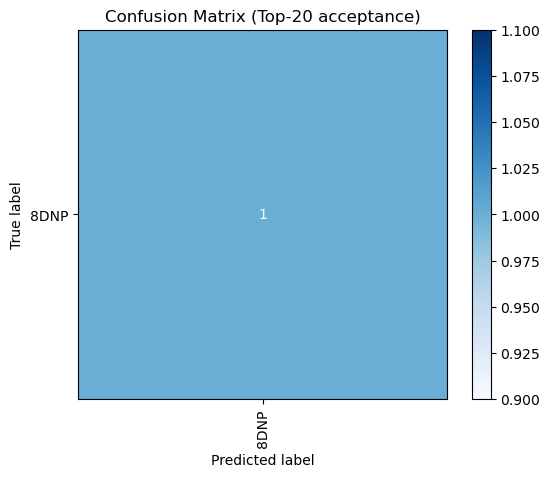

In [25]:
checkpoint_path ="/data2/atran16/ProteinClassification_AnhTuanTran/trained_results/03042026_train_120_12/CoAtNet/PDBRSTuan.pt"
image_size = (224,224)
images_per_class = ["/data2/atran16/ProteinClassification_AnhTuanTran/3D_PDB_Dataset/testingDataFromProfessorSu/METAL_BINDING_PROTEIN/8dnp/1711981358901.jpg"]
labels_per_class = [115]
top_k = 20



state = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state["net"])
model.to(device)
model.eval()
test_transform = test_tf(image_size)
# Prepare results
y_true = []
y_pred = []

for i in range(len(images_per_class)):
    img_path = images_per_class[i]
    true_label = labels_per_class[i]

    img = cv2.imread(img_path)[:, :, ::-1]  # BGR to RGB
    img_tensor = test_transform(img)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1).squeeze(0)  # shape: [num_classes]

        # Get top-k indices
        #topk_indices = torch.topk(probs, k=top_k).indices.tolist()
        topk_probs, topk_indices = torch.topk(probs, k=top_k)
        # print(topk_indices)
        # print(topk_probs)
        topkrs = list(zip(topk_indices.tolist(), topk_probs.tolist()))
        print(topkrs)
        # Accept prediction if true label is in top-k
        if true_label in topk_indices:
            pred_class = true_label
        else:
            pred_class = probs.argmax().item()

    y_true.append(true_label)
    y_pred.append(pred_class)

# Compute overall accuracy (top-k acceptance)
total_correct = sum(1 for t, p in zip(y_true, y_pred) if t == p)
topk_acc = total_correct / len(y_true)

print(f"Top-{top_k} acceptance accuracy on real dataset: {topk_acc:.2%}")

# Optional: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
unique_labels = sorted(list(set(y_true + y_pred)))
display_labels = [class_names[i] for i in unique_labels]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title(f"Confusion Matrix (Top-{top_k} acceptance)")

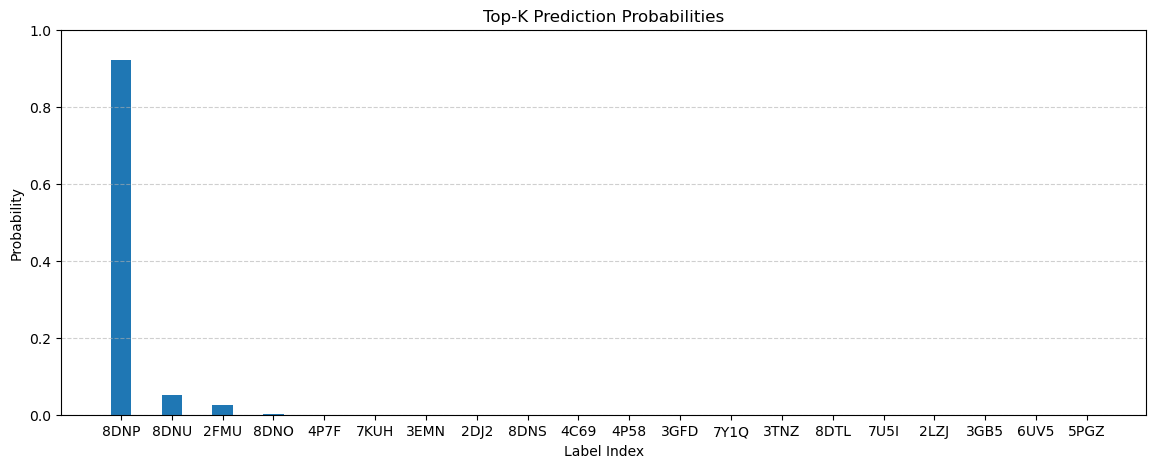

In [28]:
import matplotlib.pyplot as plt

# sort by probability (descending)
topkrs_sorted = sorted(topkrs, key=lambda x: x[1], reverse=True)

labels = [str(class_names[i[0]]) for i in topkrs_sorted]
probs = [i[1] for i in topkrs_sorted]

x = range(len(probs))

plt.figure(figsize=(14,5))   # wider figure
plt.bar(x, probs, width=0.4) # smaller width → larger gap

plt.xticks(x, labels)
plt.xlabel("Label Index")
plt.ylabel("Probability")
plt.title("Top-K Prediction Probabilities")

plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()